<a href="https://colab.research.google.com/github/Priya-DharshiniRamesh/24ADI006_DEEP-LEARNING/blob/main/DL__UNIT_3_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**24ADI306 DEEP LEARNING**

**ASSIGNMENT – 3**

**Comparative Analysis of RNN, LSTM, and GRU for Sentiment Analysis**

**Name:** Priya Dharshini R.

**Register No:** 24BAD092

**Department:** Artificial Intelligence and Data Science

**Objective:**

To implement and compare RNN, LSTM, and GRU models for sentiment classification using the IMDB movie review dataset. The models are evaluated using Accuracy, Precision, Recall, F1-score, and Training Time.

**Step 2 — Import libraries**

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import time

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("TensorFlow version:", tf.__version__)
print("Libraries imported successfully.")

TensorFlow version: 2.20.0
Libraries imported successfully.


**Step 3 — Load the dataset**

**Dataset: IMDB Movie Reviews**

The IMDB dataset contains movie reviews labeled as positive or negative sentiments.

**The sentiment labels are:**

0 – Negative

1 – Positive

The dataset is divided into training and testing sets.

In [4]:
vocab_size = 10000

(x_train, y_train), (x_test, y_test) = imdb.load_data(
    num_words=vocab_size
)

print("Dataset loaded successfully.")
print("Number of training samples:", len(x_train))
print("Number of testing samples:", len(x_test))
print("Vocabulary size:", vocab_size)

Dataset loaded successfully.
Number of training samples: 25000
Number of testing samples: 25000
Vocabulary size: 10000


**Step 4 — Explore the Dataset**

In [5]:
print("First review as encoded sequence:")
print(x_train[0])

print("\nFirst review label:")
print(y_train[0])

print("\nLength of first review:")
print(len(x_train[0]))

First review as encoded sequence:
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]

First review label:
1

Le

In [6]:
print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

print("\nNumber of positive training reviews:", np.sum(y_train == 1))
print("Number of negative training reviews:", np.sum(y_train == 0))

print("Number of positive testing reviews:", np.sum(y_test == 1))
print("Number of negative testing reviews:", np.sum(y_test == 0))

Training data shape: (25000,)
Testing data shape: (25000,)

Number of positive training reviews: 12500
Number of negative training reviews: 12500
Number of positive testing reviews: 12500
Number of negative testing reviews: 12500


**STEP 5 — Text Preprocessing**



The IMDB dataset provided by Keras is already tokenized and encoded as integer sequences.\
 Therefore, additional text tokenization was not required. Padding and truncation were performed to\
  make all input sequences have a fixed length of 200.

In [7]:
max_length = 200

x_train_pad = pad_sequences(
    x_train,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

x_test_pad = pad_sequences(
    x_test,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

print("After padding:")
print("Training data shape:", x_train_pad.shape)
print("Testing data shape:", x_test_pad.shape)

After padding:
Training data shape: (25000, 200)
Testing data shape: (25000, 200)


**STEP 6 — Create a Results Dictionary**

In [8]:
results = {
    "Model": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1-Score": [],
    "Training Time (seconds)": []
}

print("Results dictionary created.")

Results dictionary created.


**STEP 7 — Implement RNN**



A Simple Recurrent Neural Network (RNN) processes sequential data by maintaining\
information from previous time steps. It is used as the baseline model for\
sentiment classification.

In [9]:
def build_rnn_model():
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=128),
        SimpleRNN(64),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


rnn_model = build_rnn_model()

rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**STEP 8 — Train RNN**

In [10]:
start_time = time.time()

rnn_history = rnn_model.fit(
    x_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

rnn_training_time = time.time() - start_time

print("RNN training completed.")
print("RNN Training Time:", round(rnn_training_time, 2), "seconds")

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 101ms/step - accuracy: 0.5117 - loss: 0.7026 - val_accuracy: 0.5210 - val_loss: 0.6923
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 96ms/step - accuracy: 0.6043 - loss: 0.6546 - val_accuracy: 0.5188 - val_loss: 0.7008
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 32s 101ms/step - accuracy: 0.7055 - loss: 0.5156 - val_accuracy: 0.5274 - val_loss: 0.7721
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 32s 103ms/step - accuracy: 0.7410 - loss: 0.4275 - val_accuracy: 0.5194 - val_loss: 0.8459
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 103ms/step - accuracy: 0.7491 - loss: 0.4233 - val_accuracy: 0.4938 - val_loss: 0.9354
RNN training completed.
RNN Training Time: 177.58 seconds


**STEP 9 — Evaluate RNN**

In [11]:
rnn_prob = rnn_model.predict(x_test_pad, verbose=0)
rnn_pred = (rnn_prob >= 0.5).astype(int).flatten()

rnn_accuracy = accuracy_score(y_test, rnn_pred)
rnn_precision = precision_score(y_test, rnn_pred)
rnn_recall = recall_score(y_test, rnn_pred)
rnn_f1 = f1_score(y_test, rnn_pred)

results["Model"].append("RNN")
results["Accuracy"].append(rnn_accuracy)
results["Precision"].append(rnn_precision)
results["Recall"].append(rnn_recall)
results["F1-Score"].append(rnn_f1)
results["Training Time (seconds)"].append(rnn_training_time)

print("RNN Results")
print("--------------------")
print("Accuracy :", round(rnn_accuracy, 4))
print("Precision:", round(rnn_precision, 4))
print("Recall   :", round(rnn_recall, 4))
print("F1-Score :", round(rnn_f1, 4))
print("Training Time:", round(rnn_training_time, 2), "seconds")

RNN Results
--------------------
Accuracy : 0.4981
Precision: 0.4971
Recall   : 0.3198
F1-Score : 0.3892
Training Time: 177.58 seconds


**STEP 10 — Implement LSTM**



Long Short-Term Memory (LSTM) is an improved recurrent architecture that uses\
gates to control the flow of information. It is designed to handle long-term\
dependencies more effectively than a basic RNN.

In [12]:
def build_lstm_model():
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=128),
        LSTM(64),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


lstm_model = build_lstm_model()

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**STEP 11 — Train LSTM**

In [14]:
start_time = time.time()

lstm_history = lstm_model.fit(
    x_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

lstm_training_time = time.time() - start_time

print("LSTM training completed.")
print("LSTM Training Time:", round(lstm_training_time, 2), "seconds")

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 84s 268ms/step - accuracy: 0.6927 - loss: 0.5878 - val_accuracy: 0.5680 - val_loss: 0.6641
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 84s 268ms/step - accuracy: 0.6201 - loss: 0.6192 - val_accuracy: 0.6118 - val_loss: 0.6323
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 85s 273ms/step - accuracy: 0.7484 - loss: 0.4970 - val_accuracy: 0.7772 - val_loss: 0.5335
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 84s 269ms/step - accuracy: 0.8554 - loss: 0.3838 - val_accuracy: 0.8168 - val_loss: 0.4660
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 142s 268ms/step - accuracy: 0.8292 - loss: 0.4041 - val_accuracy: 0.8152 - val_loss: 0.4679
LSTM training completed.
LSTM Training Time: 479.2 seconds


**STEP 12 — Evaluate LSTM**

In [15]:
lstm_prob = lstm_model.predict(x_test_pad, verbose=0)
lstm_pred = (lstm_prob >= 0.5).astype(int).flatten()

lstm_accuracy = accuracy_score(y_test, lstm_pred)
lstm_precision = precision_score(y_test, lstm_pred)
lstm_recall = recall_score(y_test, lstm_pred)
lstm_f1 = f1_score(y_test, lstm_pred)

results["Model"].append("LSTM")
results["Accuracy"].append(lstm_accuracy)
results["Precision"].append(lstm_precision)
results["Recall"].append(lstm_recall)
results["F1-Score"].append(lstm_f1)
results["Training Time (seconds)"].append(lstm_training_time)

print("LSTM Results")
print("--------------------")
print("Accuracy :", round(lstm_accuracy, 4))
print("Precision:", round(lstm_precision, 4))
print("Recall   :", round(lstm_recall, 4))
print("F1-Score :", round(lstm_f1, 4))
print("Training Time:", round(lstm_training_time, 2), "seconds")

LSTM Results
--------------------
Accuracy : 0.8045
Precision: 0.8411
Recall   : 0.7509
F1-Score : 0.7934
Training Time: 479.2 seconds


**STEP 13 — Implement GRU**



Gated Recurrent Unit (GRU) is another gated recurrent architecture. It uses\
gating mechanisms to control information flow and has a simpler structure\
than LSTM.

In [16]:
def build_gru_model():
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=128),
        GRU(64),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


gru_model = build_gru_model()

gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**STEP 14 — Train GRU**

In [17]:
start_time = time.time()

gru_history = gru_model.fit(
    x_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

gru_training_time = time.time() - start_time

print("GRU training completed.")
print("GRU Training Time:", round(gru_training_time, 2), "seconds")

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 94s 291ms/step - accuracy: 0.5190 - loss: 0.6923 - val_accuracy: 0.5174 - val_loss: 0.6915
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 92s 293ms/step - accuracy: 0.5681 - loss: 0.6777 - val_accuracy: 0.5200 - val_loss: 0.6918
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 91s 292ms/step - accuracy: 0.6219 - loss: 0.6249 - val_accuracy: 0.7954 - val_loss: 0.4792
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 91s 290ms/step - accuracy: 0.8554 - loss: 0.3536 - val_accuracy: 0.8548 - val_loss: 0.3643
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 91s 290ms/step - accuracy: 0.9260 - loss: 0.2069 - val_accuracy: 0.8530 - val_loss: 0.3794
GRU training completed.
GRU Training Time: 458.61 seconds


 **STEP 15 — Evaluate GRU**

In [18]:
gru_prob = gru_model.predict(x_test_pad, verbose=0)
gru_pred = (gru_prob >= 0.5).astype(int).flatten()

gru_accuracy = accuracy_score(y_test, gru_pred)
gru_precision = precision_score(y_test, gru_pred)
gru_recall = recall_score(y_test, gru_pred)
gru_f1 = f1_score(y_test, gru_pred)

results["Model"].append("GRU")
results["Accuracy"].append(gru_accuracy)
results["Precision"].append(gru_precision)
results["Recall"].append(gru_recall)
results["F1-Score"].append(gru_f1)
results["Training Time (seconds)"].append(gru_training_time)

print("GRU Results")
print("--------------------")
print("Accuracy :", round(gru_accuracy, 4))
print("Precision:", round(gru_precision, 4))
print("Recall   :", round(gru_recall, 4))
print("F1-Score :", round(gru_f1, 4))
print("Training Time:", round(gru_training_time, 2), "seconds")

GRU Results
--------------------
Accuracy : 0.8353
Precision: 0.8067
Recall   : 0.8818
F1-Score : 0.8426
Training Time: 458.61 seconds


**STEP 16 — Create Comparison Table**

**Performance Comparison**

The RNN, LSTM, and GRU models are compared using Accuracy, Precision, Recall,\
F1-score, and Training Time.

In [19]:
comparison_df = pd.DataFrame(results)

comparison_df["Accuracy"] = comparison_df["Accuracy"].round(4)
comparison_df["Precision"] = comparison_df["Precision"].round(4)
comparison_df["Recall"] = comparison_df["Recall"].round(4)
comparison_df["F1-Score"] = comparison_df["F1-Score"].round(4)

comparison_df["Training Time (seconds)"] = comparison_df[
    "Training Time (seconds)"
].round(2)

comparison_df

,Model,Accuracy,Precision,Recall,F1-Score,Training Time (seconds)
0,RNN,0.4981,0.4971,0.3198,0.3892,177.58
1,LSTM,0.8045,0.8411,0.7509,0.7934,479.20
2,GRU,0.8353,0.8067,0.8818,0.8426,458.61


**STEP 17 — Plot Accuracy**

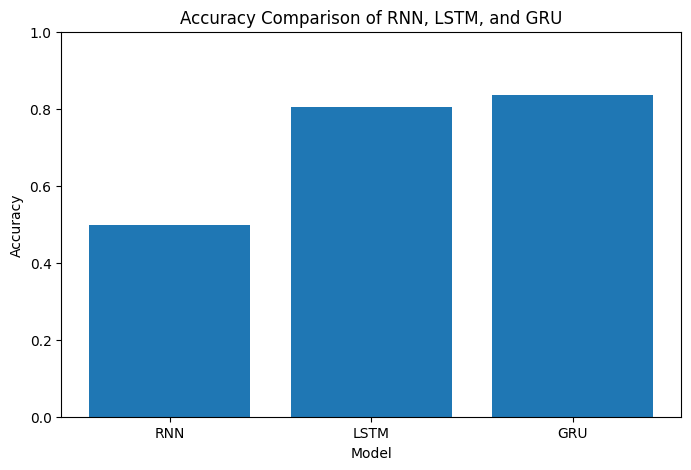

In [20]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.title("Accuracy Comparison of RNN, LSTM, and GRU")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.show()

**STEP 18 — Plot Precision, Recall and F1-score**

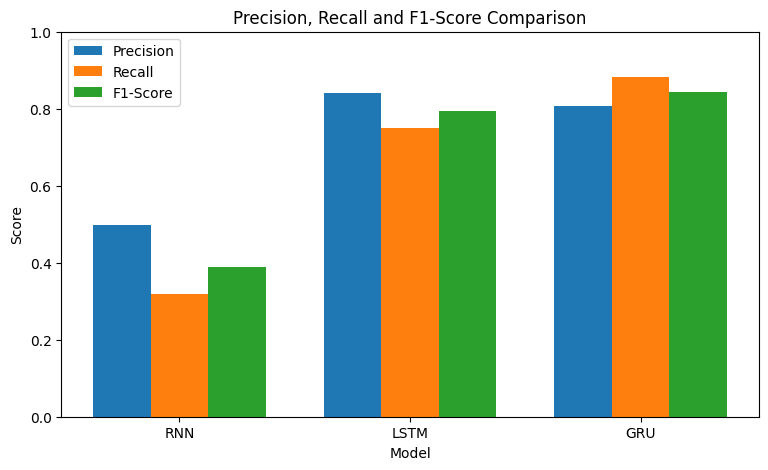

In [21]:
metrics = ["Precision", "Recall", "F1-Score"]

x = np.arange(len(comparison_df["Model"]))
width = 0.25

plt.figure(figsize=(9, 5))

for i, metric in enumerate(metrics):
    plt.bar(
        x + (i - 1) * width,
        comparison_df[metric],
        width,
        label=metric
    )

plt.xticks(x, comparison_df["Model"])
plt.ylabel("Score")
plt.xlabel("Model")
plt.title("Precision, Recall and F1-Score Comparison")
plt.ylim(0, 1)
plt.legend()

plt.show()

**STEP 19 — Plot Training Time**

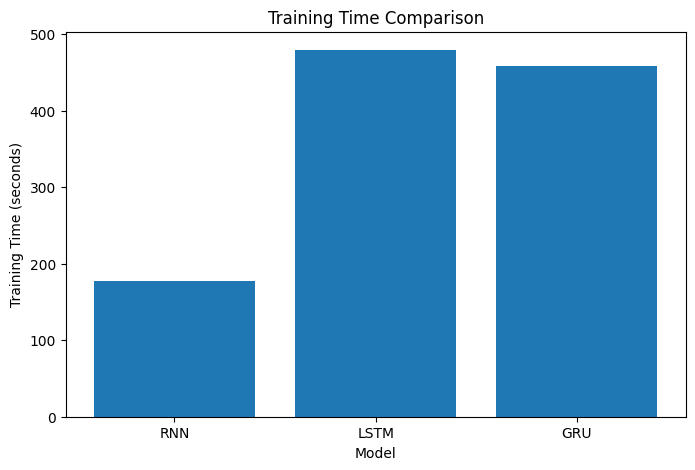

In [22]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Training Time (seconds)"]
)

plt.title("Training Time Comparison")
plt.xlabel("Model")
plt.ylabel("Training Time (seconds)")

plt.show()

**STEP 20 — Plot Training Accuracy**



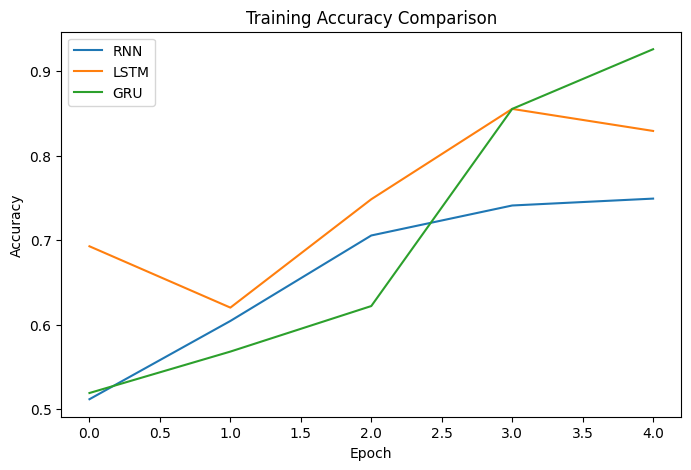

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(rnn_history.history["accuracy"], label="RNN")
plt.plot(lstm_history.history["accuracy"], label="LSTM")
plt.plot(gru_history.history["accuracy"], label="GRU")

plt.title("Training Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

**STEP 21 — Plot Validation Accuracy**

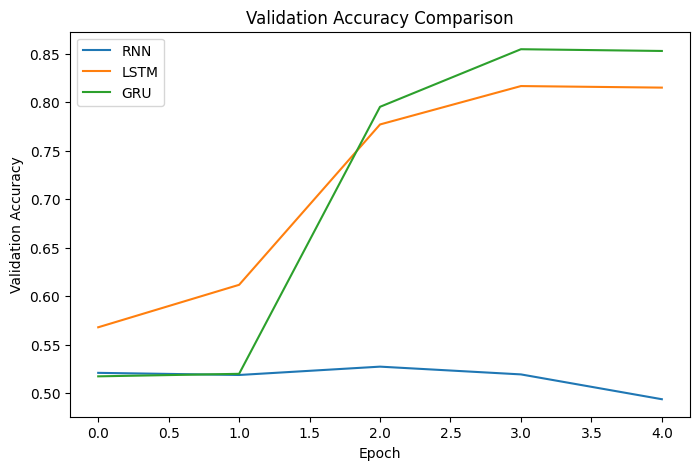

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(rnn_history.history["val_accuracy"], label="RNN")
plt.plot(lstm_history.history["val_accuracy"], label="LSTM")
plt.plot(gru_history.history["val_accuracy"], label="GRU")

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()

plt.show()

**STEP 22 — Find the Best Results Automatically**

In [25]:
best_accuracy_model = comparison_df.loc[
    comparison_df["Accuracy"].idxmax(), "Model"
]

best_f1_model = comparison_df.loc[
    comparison_df["F1-Score"].idxmax(), "Model"
]

fastest_model = comparison_df.loc[
    comparison_df["Training Time (seconds)"].idxmin(), "Model"
]

print("Highest Accuracy Model:", best_accuracy_model)
print("Highest F1-Score Model:", best_f1_model)
print("Fastest Training Model:", fastest_model)

Highest Accuracy Model: GRU
Highest F1-Score Model: GRU
Fastest Training Model: RNN


**STEP 23 — Final Analysis**



The performance of RNN, LSTM, and GRU models was compared using Accuracy, Precision, Recall, F1-score, and Training Time for sentiment classification on the IMDB movie review dataset.

The RNN model achieved an accuracy of 49.81%, precision of 49.71%, recall of 31.98%, and F1-score of 38.92%. It required 177.58 seconds for training, making it the fastest model among the three. However, its lower performance indicates that the basic RNN was less effective in learning the sentiment patterns in the review sequences.

The LSTM model achieved an accuracy of 80.45%, precision of 84.11%, recall of 75.09%, and F1-score of 79.34%. It required 479.20 seconds for training. Compared with RNN, LSTM provided much better classification performance, showing the advantage of using a gated recurrent architecture for handling sequential text data.

The GRU model achieved the highest accuracy of 83.53% and the highest F1-score of 84.26%. It achieved a precision of 80.67% and recall of 88.18%, with a training time of 458.61 seconds. Therefore, GRU provided the best overall classification performance in this experiment and also required slightly less training time than LSTM.

Overall, GRU was the best-performing model based on Accuracy and F1-score, while RNN was the fastest model to train. The results show that gated recurrent architectures, particularly GRU in this experiment, were more effective than the basic RNN for sentiment classification.


**STEP 24 — Conclusion**


In this experiment, RNN, LSTM, and GRU models were implemented and compared for sentiment analysis using the IMDB movie review dataset. The dataset provided by Keras was already tokenized and encoded as integer sequences, so padding and truncation were performed to make all input sequences have a fixed length of 200.

The experimental results show that RNN was the fastest model with a training time of 177.58 seconds, but it achieved the lowest classification performance with an accuracy of 49.81% and an F1-score of 38.92%. LSTM performed significantly better, achieving an accuracy of 80.45% and an F1-score of 79.34%. GRU achieved the highest accuracy of 83.53% and the highest F1-score of 84.26%, with a training time of 458.61 seconds.

Therefore, based on the results of this experiment, GRU performed best for sentiment classification, while RNN required the least training time. The experiment demonstrates that gated recurrent models can handle sequential text data more effectively than a basic RNN.

